Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  4.55it/s]
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


Time Taken: 0.43346309661865234


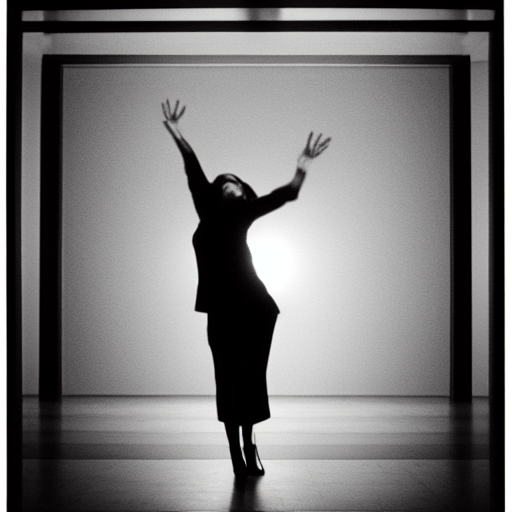

In [7]:
import torch
from diffusers import DiffusionPipeline, LCMScheduler   
import time

# 1. Load the base model (SD v1.5)
model_id = "runwayml/stable-diffusion-v1-5"
pipe = DiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False)

# pipe.enable_attention_slicing() # Activate this to reduce VRAM usage
pipe.set_progress_bar_config(disable=True)

# 2. Load the LCM-LoRA adapter
pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
pipe.fuse_lora() # Fuses weights for faster inference

# 3. Switch to LCM Scheduler (Crucial for speed)
pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config) # The LCMScheduler is required in conjucntion with the LORA as it facilitates the reduction in the num_inference_steps to 4. 
pipe.to("cuda")

# 4. Generation Loop
prompt = "A single person standing centered in the frame, symmetrical composition, subject perfectly centered, straight-on camera angle, portrait photography, subject aligned with image center, balanced framing"


start_time = time.time()
image = pipe(
    prompt=[prompt],
    num_inference_steps=4,  # LCM needs only 4 steps, < 4 distorts the images whilst > 4 doesn't produce any noticable benefit
    guidance_scale=1      # LCM works best with guidance between 0 and 2
).images[0]
print(f"Time Taken: {time.time() - start_time}")

display(image)

Loading pipeline components...: 100%|██████████| 6/6 [00:01<00:00,  5.96it/s]


Time Taken: 5.171895742416382


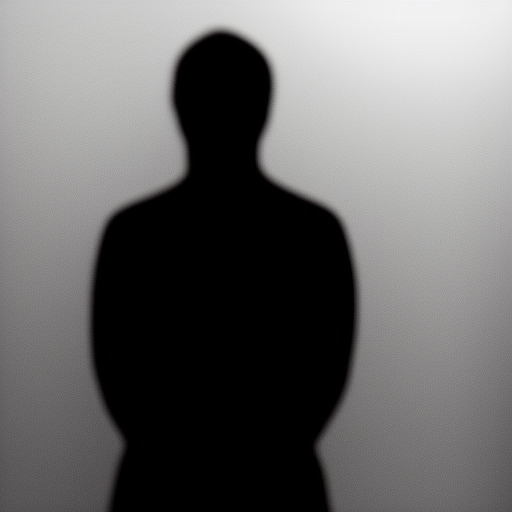

In [ ]:
import torch
from diffusers import DiffusionPipeline, LCMScheduler   
import time

# 1. Load the base model (SD v1.5)
model_id = "runwayml/stable-diffusion-v1-5"
pipe = DiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, safety_checker=None, requires_safety_checker=False)

# pipe.enable_attention_slicing() # Activate this to reduce VRAM usage
pipe.set_progress_bar_config(disable=True)

# # 2. Load the LCM-LoRA adapter
# pipe.load_lora_weights("latent-consistency/lcm-lora-sdv1-5")
# pipe.fuse_lora() # Fuses weights for faster inference

# 3. Switch to LCM Scheduler (Crucial for speed)
# pipe.scheduler = LCMScheduler.from_config(pipe.scheduler.config) # The LCMScheduler is required in conjucntion with the LORA as it facilitates the reduction in the num_inference_steps to 4. 
pipe.to("cuda")

# 4. Generation Loop
prompt = "A single person standing on the far left side of the frame, off-center composition, subject positioned left" #, negative space on the right, rule of thirds, environmental portrait, cinematic framing"


start_time = time.time()
image = pipe(
    prompt=[prompt],
    # num_inference_steps=4,  # LCM needs only 4 steps, < 4 distorts the images whilst > 4 doesn't produce any noticable benefit
    # guidance_scale=1      # LCM works best with guidance between 0 and 2
).images[0]
print(f"Time Taken: {time.time() - start_time}")

display(image)